In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [72]:
url = "https://raw.githubusercontent.com/kalindugavesh/FIFA/refs/heads/main/Fulldataset1.csv"
url

'https://raw.githubusercontent.com/kalindugavesh/FIFA/refs/heads/main/Fulldataset1.csv'

In [107]:
data = pd.read_csv(url)
data

,Unnamed: 0,Match,Team1,Team2,Match_Date,Team1_Recent_form,Team2_Recent_form,Team1_rank,Team2_rank,Team1_Star_Player_Count,Team1_Top100_players,Team2_Star_Player_Count,Team2_Top100_players,Head_to_Head_Team1_result_percentage,Team1_Result,Team1_goalkeeper_rank,Team2_goalkeeper_rank
0,0,2002FrancevsSenagal,France,Senegal,5/31/2002,3.5,3.5,1,42,1,6,0,2,0.000,Loss,3,19
1,1,2002UruguayvsDenmark,Uruguay,Denmark,6/1/2002,2.5,4.0,24,20,0,1,0,2,0.000,Loss,14,9
2,2,2002DenmarkvsSenegal,Denmark,Senegal,6/6/2002,4.0,3.5,20,42,0,2,0,2,0.750,Draw,9,19
3,3,2002FrancevsUruguay,France,Uruguay,6/6/2002,2.5,2.5,1,24,1,6,0,1,0.375,Draw,3,14
4,4,2002DenmarkvsFrance,Denmark,France,6/11/2002,4.5,2.0,20,1,0,2,1,6,0.500,Win,9,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,378,2022MorvsPor,Morocco,Portugal,12/10/2022,4.0,4.0,22,9,1,3,3,6,0.500,Win,16,7
379,379,2022ArgvsCro,Argentina,Croatia,12/13/2022,3.5,3.0,3,12,3,6,2,4,0.500,Win,5,10
380,380,2022FravsMor,France,Morocco,12/14/2022,4.0,4.0,4,22,4,8,1,3,0.800,Win,4,16
381,381,2022_Final_ArgvsFra,Argentina,France,12/18/2022,4.5,4.0,3,4,3,6,4,8,0.625,Draw,5,4


In [109]:
import joblib

In [110]:
d_list =  ["Unnamed: 0","Match","Team1","Team2","Match_Date","Team1_Result"]
x = data.drop(d_list,axis=1)
y = data["Team1_Result"]

In [56]:
x

,Team1_Recent_form,Team2_Recent_form,Team1_rank,Team2_rank,Team1_Star_Player_Count,Team1_Top100_players,Team2_Star_Player_Count,Team2_Top100_players,Head_to_Head_Team1_result_percentage,Team1_goalkeeper_rank,Team2_goalkeeper_rank
0,3.5,3.5,1,42,1,6,0,2,0.000,3,19
1,2.5,4.0,24,20,0,1,0,2,0.000,14,9
2,4.0,3.5,20,42,0,2,0,2,0.750,9,19
3,2.5,2.5,1,24,1,6,0,1,0.375,3,14
4,4.5,2.0,20,1,0,2,1,6,0.500,9,3
...,...,...,...,...,...,...,...,...,...,...,...
378,4.0,4.0,22,9,1,3,3,6,0.500,16,7
379,3.5,3.0,3,12,3,6,2,4,0.500,5,10
380,4.0,4.0,4,22,4,8,1,3,0.800,4,16
381,4.5,4.0,3,4,3,6,4,8,0.625,5,4


In [111]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

## Basic Model

In [112]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [113]:
predic = model.predict(x_test)
predic

array(['Loss', 'Win', 'Win', 'Win', 'Loss', 'Draw', 'Loss', 'Loss', 'Win',
       'Win', 'Loss', 'Win', 'Win', 'Win', 'Win', 'Loss', 'Loss', 'Win',
       'Win', 'Loss', 'Win', 'Loss', 'Win', 'Win', 'Loss', 'Win', 'Win',
       'Loss', 'Loss', 'Win', 'Loss', 'Loss', 'Win', 'Win', 'Win', 'Win',
       'Win', 'Loss', 'Loss', 'Win', 'Win', 'Loss', 'Loss', 'Win', 'Win',
       'Win', 'Loss', 'Loss', 'Loss', 'Win', 'Win', 'Loss', 'Win', 'Loss',
       'Win', 'Win', 'Win', 'Win', 'Loss', 'Loss', 'Loss', 'Loss', 'Win',
       'Loss', 'Loss', 'Win', 'Loss', 'Win', 'Win', 'Loss', 'Draw',
       'Loss', 'Win', 'Draw', 'Win', 'Loss', 'Loss', 'Win', 'Win', 'Win',
       'Loss', 'Win', 'Win', 'Loss', 'Win', 'Loss', 'Loss', 'Win', 'Win',
       'Loss', 'Loss', 'Loss', 'Win', 'Win', 'Loss', 'Loss', 'Loss',
       'Win', 'Loss', 'Win', 'Win', 'Win', 'Loss', 'Win', 'Loss', 'Loss',
       'Win', 'Loss', 'Win', 'Win', 'Loss', 'Win', 'Win', 'Loss', 'Draw'],
      dtype=object)

In [114]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,predic)

0.6434782608695652

In [115]:
from sklearn.ensemble import RandomForestClassifier
model_RF = RandomForestClassifier(n_estimators=100)
model_RF.fit(x_train,y_train)

RandomForestClassifier()

In [116]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,model_RF.predict(x_test))

0.6173913043478261

## Basic model Accuracy Comparison

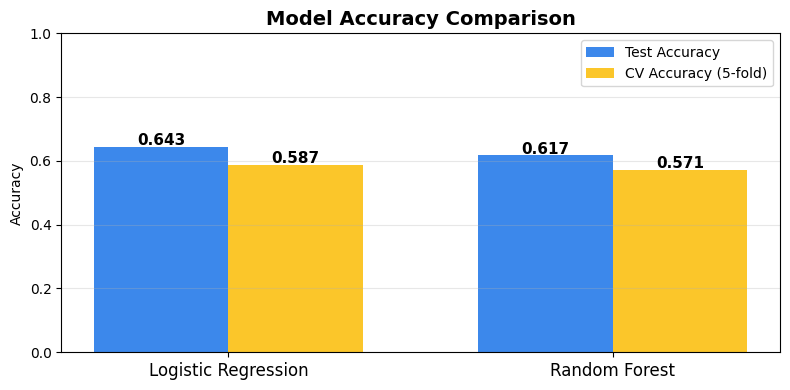

In [117]:
from sklearn.model_selection import cross_val_score

names = ["Logistic Regression", "Random Forest"]
accs  = [accuracy_score(y_test,model.predict(x_test)), accuracy_score(y_test, model_RF.predict(x_test))]
cvs   = [cross_val_score(model, x, y, cv=5).mean(),
         cross_val_score(model_RF, x, y, cv=5).mean()]

x = np.arange(len(names)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w/2, accs, w, label="Test Accuracy",      color="#1a73e8", alpha=0.85)
b2 = ax.bar(x + w/2, cvs,  w, label="CV Accuracy (5-fold)",color="#fbbc04", alpha=0.85)
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f"{b.get_height():.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=12)
ax.set_ylim(0, 1); ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Basic Model Pre Class Score

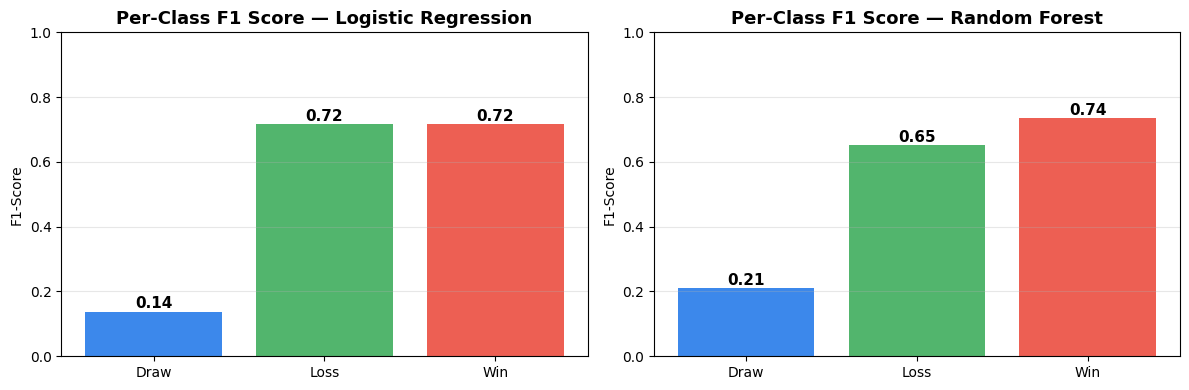

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#1a73e8","#34a853","#ea4335"]
for ax, preds, name in zip(axes,
                            [model.predict(x_test), model_RF.predict(x_test)],
                            ["Logistic Regression", "Random Forest"]):
    report = classification_report(y_test, preds, output_dict=True)
    labels = [k for k in report if k not in
              ("accuracy","macro avg","weighted avg")]
    f1s = [report[k]["f1-score"] for k in labels]
    bars = ax.bar(labels, f1s, color=colors[:len(labels)], alpha=0.85)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                f"{b.get_height():.2f}", ha="center", fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1); ax.set_ylabel("F1-Score")
    ax.set_title(f"Per-Class F1 Score — {name}", fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Feature Importance

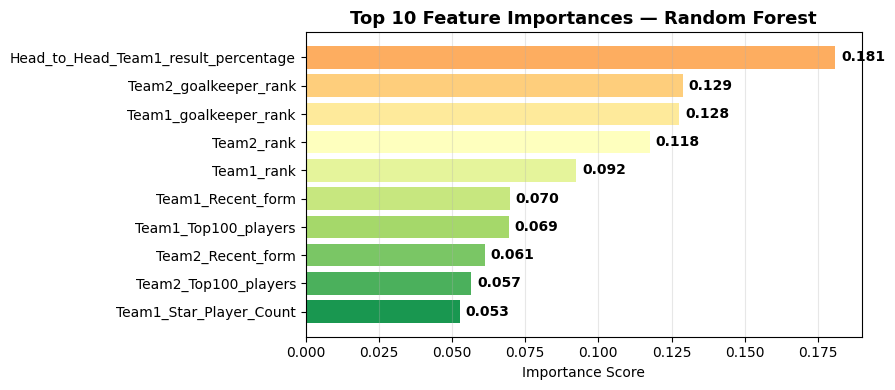

In [122]:
fi = pd.Series(model_RF.feature_importances_,
               index=x_train.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi)))
bars = ax.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1])
for b in bars:
    ax.text(b.get_width()+0.002, b.get_y()+b.get_height()/2,
            f"{b.get_width():.3f}", va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.set_title("Top 10 Feature Importances — Random Forest",
             fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

## Basic model Confusion Matrix

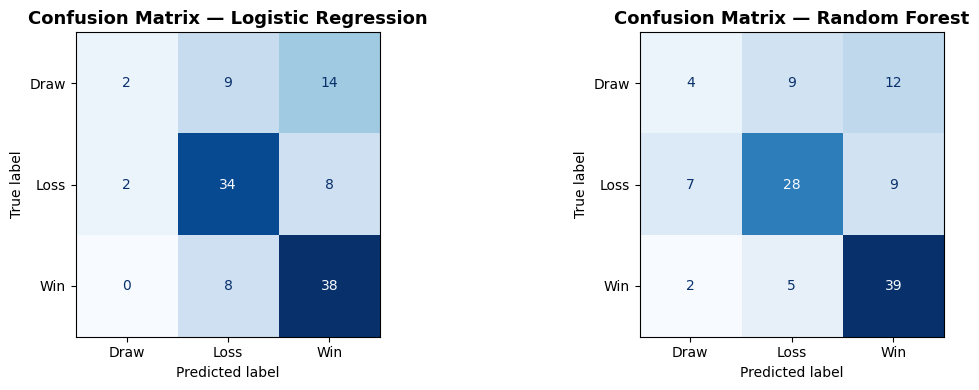

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, name in zip(axes,
                            [model.predict(x_test), model_RF.predict(x_test)],
                            ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Draw","Loss","Win"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

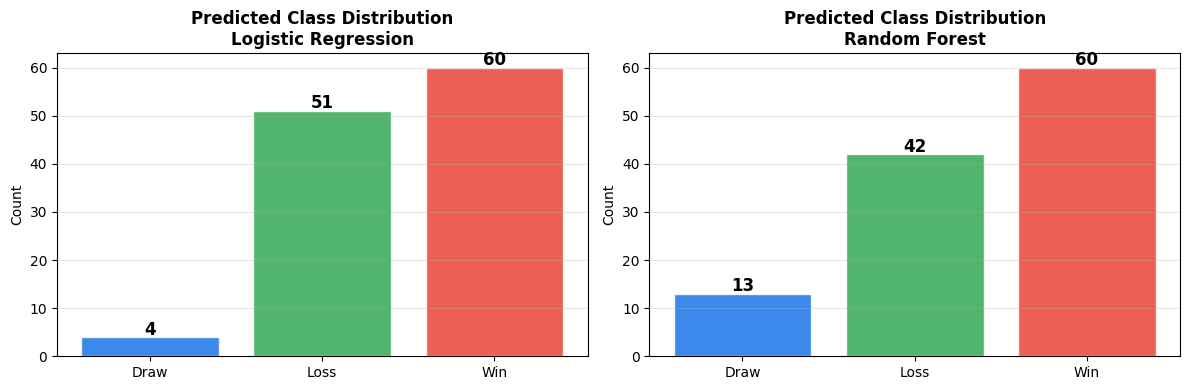

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#1a73e8","#34a853","#ea4335"]
for ax, preds, name in zip(axes,
                            [model.predict(x_test), model_RF.predict(x_test)],
                            ["Logistic Regression", "Random Forest"]):
    unique, counts = np.unique(preds, return_counts=True)
    bars = ax.bar(unique, counts, color=colors[:len(unique)], alpha=0.85, edgecolor="white")
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                str(int(b.get_height())), ha="center", fontsize=12, fontweight="bold")
    ax.set_ylabel("Count"); ax.set_title(f"Predicted Class Distribution\n{name}", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Basic Model Predicted Counts

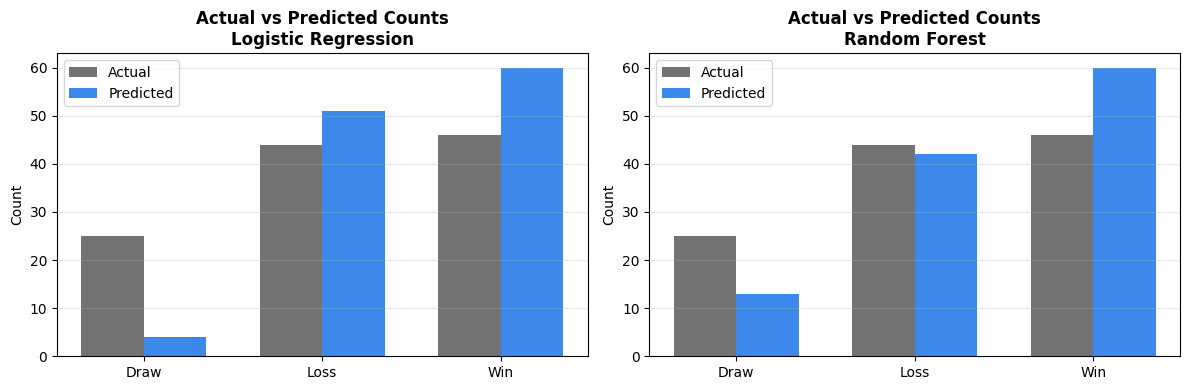

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
classes = sorted(y_test.unique())
actual_counts = [sum(y_test == c) for c in classes]
for ax, preds, name in zip(axes,
                            [model.predict(x_test), model_RF.predict(x_test)],
                            ["Logistic Regression", "Random Forest"]):
    pred_counts = [sum(preds == c) for c in classes]
    x_pos = np.arange(len(classes)); w = 0.35
    ax.bar(x_pos - w/2, actual_counts, w, label="Actual",    color="#444", alpha=0.75)
    ax.bar(x_pos + w/2, pred_counts,   w, label="Predicted", color="#1a73e8", alpha=0.85)
    ax.set_xticks(x_pos); ax.set_xticklabels(classes)
    ax.set_ylabel("Count"); ax.legend()
    ax.set_title(f"Actual vs Predicted Counts\n{name}", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

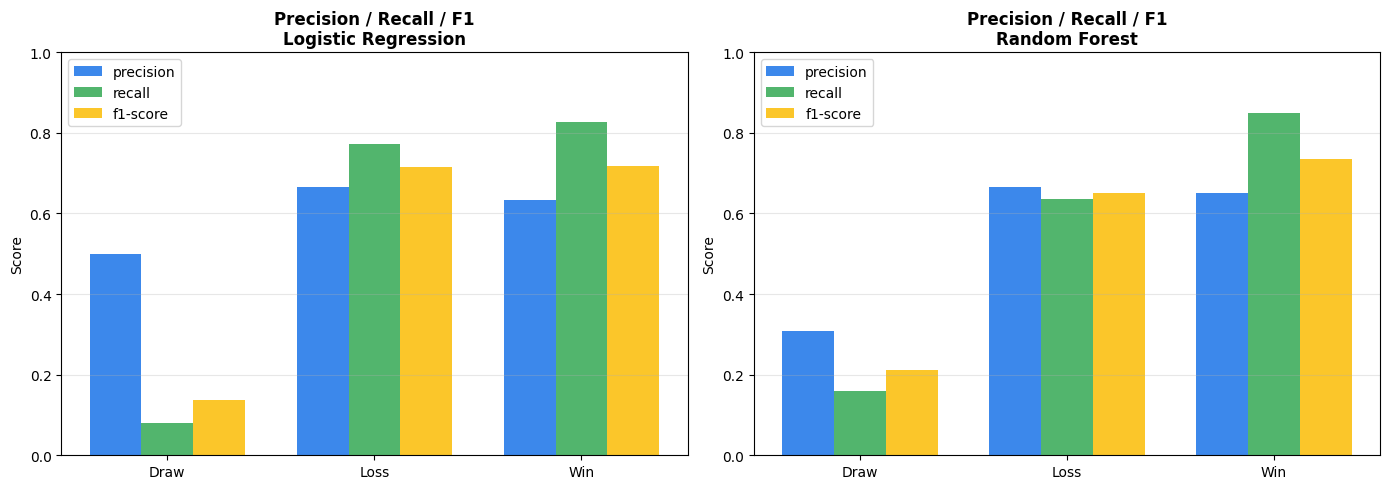

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ["precision", "recall", "f1-score"]
metric_colors = ["#1a73e8", "#34a853", "#fbbc04"]
for ax, preds, name in zip(axes,
                            [model.predict(x_test), model_RF.predict(x_test)],
                            ["Logistic Regression", "Random Forest"]):
    report = classification_report(y_test, preds, output_dict=True)
    labels = [k for k in report if k not in ("accuracy","macro avg","weighted avg")]
    x_pos = np.arange(len(labels)); w = 0.25
    for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
        vals = [report[l][metric] for l in labels]
        ax.bar(x_pos + i*w - w, vals, w, label=metric, color=color, alpha=0.85)
    ax.set_xticks(x_pos); ax.set_xticklabels(labels)
    ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.legend()
    ax.set_title(f"Precision / Recall / F1\n{name}", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

##Feature Correlation with Team1_Result

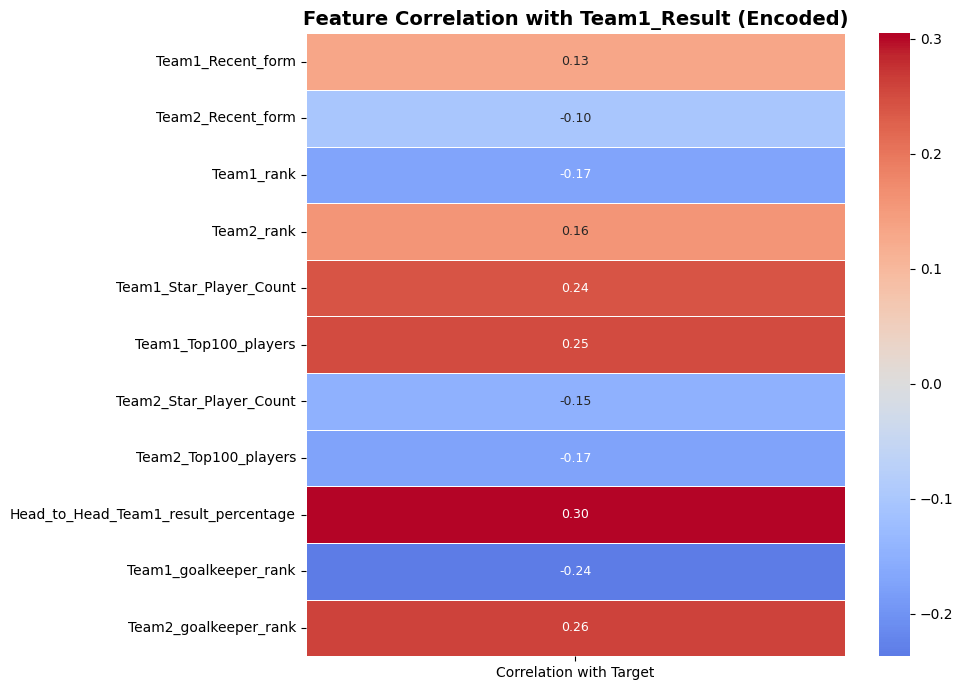

In [180]:
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

fig, ax = plt.subplots(figsize=(10, 7))

# Define the list of columns to drop to get purely numerical features
d_list_features = ["Unnamed: 0", "Match", "Team1", "Team2", "Match_Date", "Team1_Result"]
x_numerical_features = data.drop(d_list_features, axis=1)

# Encode the target variable 'Team1_Result' into numerical format
le = LabelEncoder()
y_encoded = le.fit_transform(data["Team1_Result"])
y_encoded_series = pd.Series(y_encoded, index=data.index, name="Team1_Result_Encoded")

# Create a temporary DataFrame by combining the numerical features and the encoded target
df_for_correlation_plot = pd.concat([x_numerical_features, y_encoded_series], axis=1)

# Calculate the correlation of all columns with the encoded 'Team1_Result_Encoded'
# Drop the self-correlation of 'Team1_Result_Encoded' with itself
corr_series = df_for_correlation_plot.corr()['Team1_Result_Encoded'].drop('Team1_Result_Encoded')

# Convert the Series to a DataFrame for plotting with sns.heatmap
# No mask is needed for a single column heatmap.
sns.heatmap(corr_series.to_frame(name="Correlation with Target"),
            annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 9})
ax.set_title("Feature Correlation with Team1_Result (Encoded)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## basic Models Accuracy

In [134]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary = []
for preds, name in zip([model.predict(x_test), model_RF.predict(x_test)],
                        ["Logistic Regression", "Random Forest"]):
    summary.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds, average="weighted"), 4),
        "Recall":    round(recall_score(y_test, preds, average="weighted"), 4),
        "F1 Score":  round(f1_score(y_test, preds, average="weighted"), 4),
    })

summary_df = pd.DataFrame(summary).set_index("Model")
summary_df.style.background_gradient(cmap="YlGn", axis=0).format("{:.4f}")

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.6435,0.6171,0.6435,0.5906
Random Forest,0.6174,0.5820,0.6174,0.5892


Class distribution in training set:
Team1_Result
Win     120
Loss     85
Draw     63
Name: count, dtype: int64

Class distribution (%):
Team1_Result
Win     44.8
Loss    31.7
Draw    23.5
Name: proportion, dtype: float64


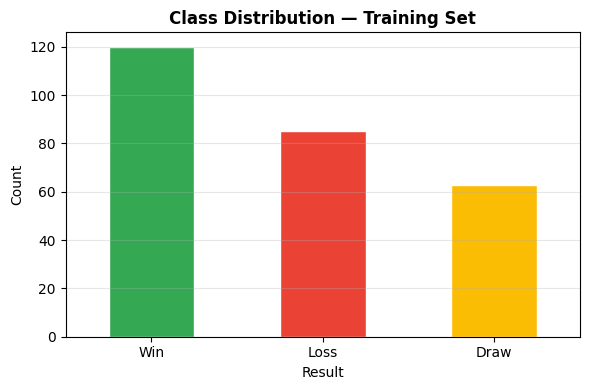

In [135]:
print("Class distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution (%):")
print(y_train.value_counts(normalize=True).mul(100).round(1))

y_train.value_counts().plot(kind="bar", color=["#34a853","#ea4335","#fbbc04"],
                             edgecolor="white", figsize=(6,4))
plt.title("Class Distribution — Training Set", fontweight="bold")
plt.xlabel("Result"); plt.ylabel("Count")
plt.xticks(rotation=0); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Make Tuning The New Model In Logistcis Regression

In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    "C":           [0.01, 0.1, 1, 10, 100],
    "solver":      ["lbfgs", "saga"],
    "max_iter":    [500, 1000, 2000],
    "class_weight": ["balanced", None]
}

model_tuned = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)
model_tuned.fit(x_train, y_train)

print("\n Best parameters found:")
print(model_tuned.best_params_)
print(f"\n Best CV F1 score: {model_tuned.best_score_:.4f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits

✅ Best parameters found:
{'C': 10, 'class_weight': 'balanced', 'max_iter': 2000, 'solver': 'saga'}

✅ Best CV F1 score: 0.5361


In [137]:
pred_original = model.predict(x_test)
pred_tuned    = model_tuned.best_estimator_.predict(x_test)

acc_original = accuracy_score(y_test, pred_original)
acc_tuned    = accuracy_score(y_test, pred_tuned)

print("=== Original Logistic Regression ===")
print(f"Accuracy: {acc_original:.4f}")
print(classification_report(y_test, pred_original))

print("=== Tuned + Balanced Logistic Regression ===")
print(f"Accuracy: {acc_tuned:.4f}")
print(classification_report(y_test, pred_tuned))

=== Original Logistic Regression ===
Accuracy: 0.6435
              precision    recall  f1-score   support

        Draw       0.50      0.08      0.14        25
        Loss       0.67      0.77      0.72        44
         Win       0.63      0.83      0.72        46

    accuracy                           0.64       115
   macro avg       0.60      0.56      0.52       115
weighted avg       0.62      0.64      0.59       115

=== Tuned + Balanced Logistic Regression ===
Accuracy: 0.6087
              precision    recall  f1-score   support

        Draw       0.38      0.48      0.42        25
        Loss       0.63      0.55      0.59        44
         Win       0.76      0.74      0.75        46

    accuracy                           0.61       115
   macro avg       0.59      0.59      0.58       115
weighted avg       0.63      0.61      0.61       115



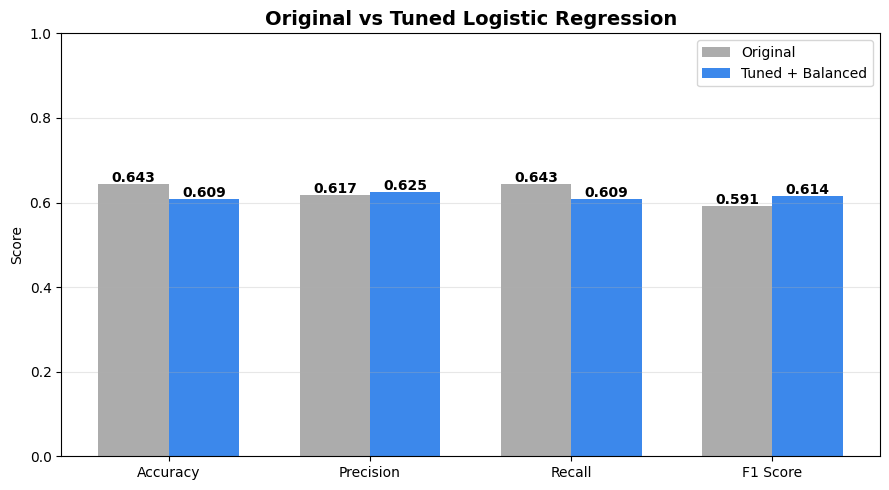

In [138]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_original = {
    "Accuracy":  accuracy_score(y_test, pred_original),
    "Precision": precision_score(y_test, pred_original, average="weighted"),
    "Recall":    recall_score(y_test, pred_original, average="weighted"),
    "F1 Score":  f1_score(y_test, pred_original, average="weighted"),
}
metrics_tuned = {
    "Accuracy":  accuracy_score(y_test, pred_tuned),
    "Precision": precision_score(y_test, pred_tuned, average="weighted"),
    "Recall":    recall_score(y_test, pred_tuned, average="weighted"),
    "F1 Score":  f1_score(y_test, pred_tuned, average="weighted"),
}

labels = list(metrics_original.keys())
x_pos  = np.arange(len(labels)); w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x_pos - w/2, metrics_original.values(), w,
            label="Original", color="#9e9e9e", alpha=0.85)
b2 = ax.bar(x_pos + w/2, metrics_tuned.values(),    w,
            label="Tuned + Balanced", color="#1a73e8", alpha=0.85)
for b in list(b1) + list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f"{b.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_ylim(0, 1); ax.set_ylabel("Score")
ax.set_title("Original vs Tuned Logistic Regression", fontsize=14, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

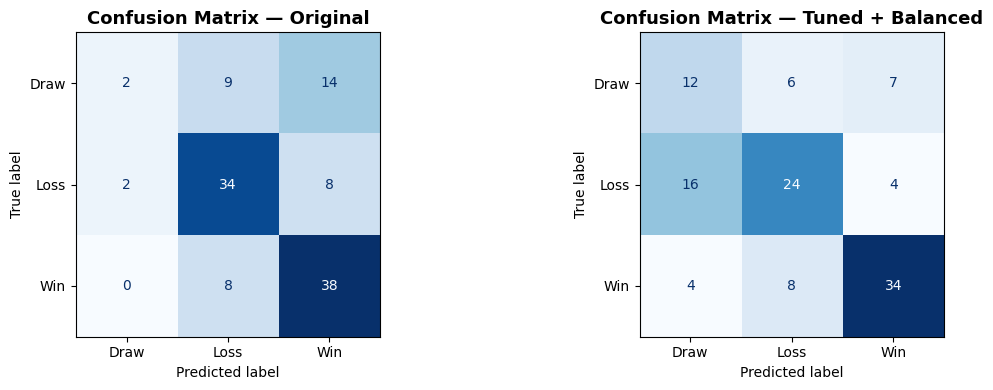

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, name in zip(axes,
                            [pred_original, pred_tuned],
                            ["Original", "Tuned + Balanced"]):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Draw","Loss","Win"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## C Parameter Sensitivity

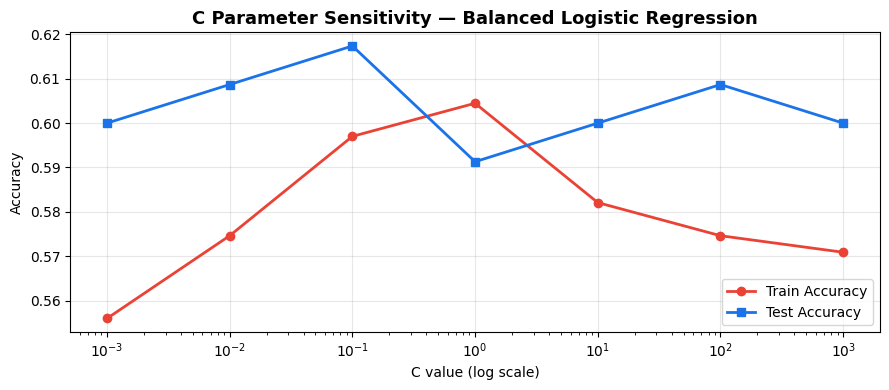

In [140]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_scores, test_scores = [], []

for C in C_values:
    m = LogisticRegression(C=C, max_iter=1000, class_weight="balanced", random_state=42)
    m.fit(x_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(x_train)))
    test_scores.append(accuracy_score(y_test,  m.predict(x_test)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(C_values, train_scores, "o-", color="#ea4335", label="Train Accuracy", linewidth=2)
ax.plot(C_values, test_scores,  "s-", color="#1a73e8", label="Test Accuracy",  linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("C value (log scale)"); ax.set_ylabel("Accuracy")
ax.set_title("C Parameter Sensitivity — Balanced Logistic Regression",
             fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Best Model Create With Tuned Parameters

In [141]:
# Use the best C value from the chart
model_best = LogisticRegression(
    C=0.1,
    solver="lbfgs",
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
model_best.fit(x_train, y_train)
print("Final model accuracy:", accuracy_score(y_test, model_best.predict(x_test)))

Final model accuracy: 0.6173913043478261


## Prediction Count

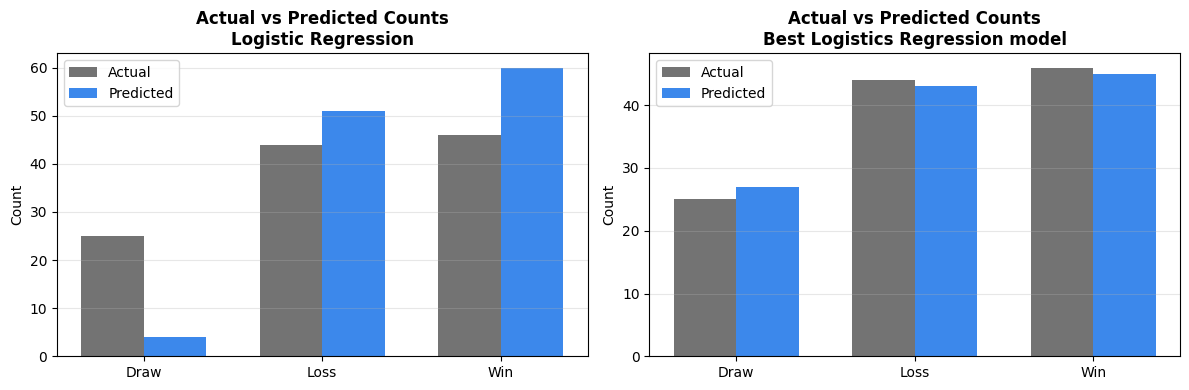

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
classes = sorted(y_test.unique())
actual_counts = [sum(y_test == c) for c in classes]
for ax, preds, name in zip(axes,
                            [model.predict(x_test), model_best.predict(x_test)],
                            ["Logistic Regression", "Best Logistics Regression model"]):
    pred_counts = [sum(preds == c) for c in classes]
    x_pos = np.arange(len(classes)); w = 0.35
    ax.bar(x_pos - w/2, actual_counts, w, label="Actual",    color="#444", alpha=0.75)
    ax.bar(x_pos + w/2, pred_counts,   w, label="Predicted", color="#1a73e8", alpha=0.85)
    ax.set_xticks(x_pos); ax.set_xticklabels(classes)
    ax.set_ylabel("Count"); ax.legend()
    ax.set_title(f"Actual vs Predicted Counts\n{name}", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Make New Random Forest Model In tunining

In [148]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "n_estimators":      [50, 100, 200, 300],
    "max_depth":         [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "class_weight":      ["balanced", None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(x_train, y_train)

print("\n Best parameters found:")
print(grid_rf.best_params_)
print(f"\n Best CV F1 score: {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

✅ Best parameters found:
{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}

✅ Best CV F1 score: 0.5725


## n_estimators Sensitivity

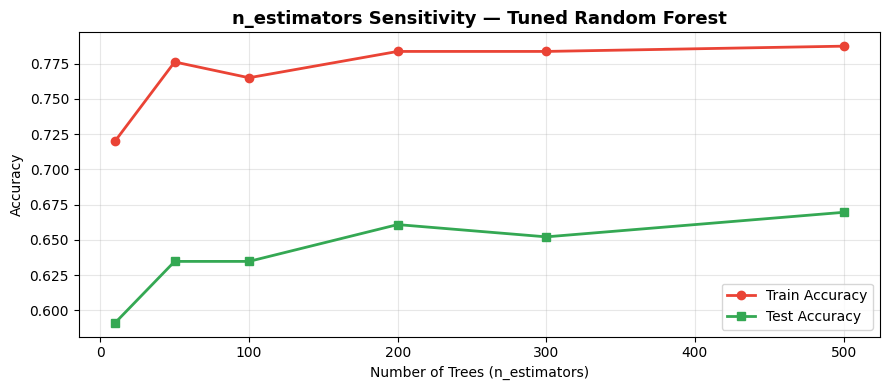

In [149]:
n_values = [10, 50, 100, 200, 300, 500]
train_scores, test_scores = [], []

best = grid_rf.best_params_

for n in n_values:
    m = RandomForestClassifier(
        n_estimators      = n,
        max_depth         = best["max_depth"],
        min_samples_split = best["min_samples_split"],
        min_samples_leaf  = best["min_samples_leaf"],
        class_weight      = best["class_weight"],
        random_state=42
    )
    m.fit(x_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(x_train)))
    test_scores.append(accuracy_score(y_test,  m.predict(x_test)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_values, train_scores, "o-", color="#ea4335", label="Train Accuracy", linewidth=2)
ax.plot(n_values, test_scores,  "s-", color="#34a853", label="Test Accuracy",  linewidth=2)
ax.set_xlabel("Number of Trees (n_estimators)"); ax.set_ylabel("Accuracy")
ax.set_title("n_estimators Sensitivity — Tuned Random Forest",
             fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

##max_depth Sensitivity

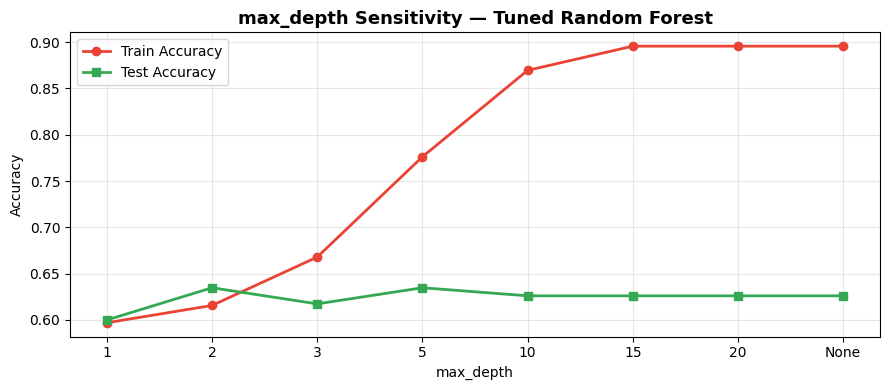

In [150]:
depth_values = [1, 2, 3, 5, 10, 15, 20, None]
train_scores, test_scores, labels_d = [], [], []

for d in depth_values:
    m = RandomForestClassifier(
        n_estimators      = best["n_estimators"],
        max_depth         = d,
        min_samples_split = best["min_samples_split"],
        min_samples_leaf  = best["min_samples_leaf"],
        class_weight      = best["class_weight"],
        random_state=42
    )
    m.fit(x_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(x_train)))
    test_scores.append(accuracy_score(y_test,  m.predict(x_test)))
    labels_d.append(str(d))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(labels_d, train_scores, "o-", color="#ea4335", label="Train Accuracy", linewidth=2)
ax.plot(labels_d, test_scores,  "s-", color="#34a853", label="Test Accuracy",  linewidth=2)
ax.set_xlabel("max_depth"); ax.set_ylabel("Accuracy")
ax.set_title("max_depth Sensitivity — Tuned Random Forest",
             fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [159]:
model_RF_best = RandomForestClassifier(
    n_estimators      = 700,
    max_depth         = 5,        # from max_depth chart
    min_samples_split = best["min_samples_split"],
    min_samples_leaf  = best["min_samples_leaf"],
    class_weight      = "balanced",
    random_state      = 42
)
model_RF_best.fit(x_train, y_train)
pred_rf_best = model_RF_best.predict(x_test)

print("Best RF Accuracy:", round(accuracy_score(y_test, pred_rf_best), 4))
print(classification_report(y_test, pred_rf_best))

Best RF Accuracy: 0.6696
              precision    recall  f1-score   support

        Draw       0.39      0.52      0.45        25
        Loss       0.76      0.64      0.69        44
         Win       0.80      0.78      0.79        46

    accuracy                           0.67       115
   macro avg       0.65      0.65      0.64       115
weighted avg       0.70      0.67      0.68       115



## Compaire all modes

                    Accuracy  Precision  Recall  F1 Score
Model                                                    
Original LR           0.6435     0.6171  0.6435    0.5906
Tuned LR              0.6174     0.6230  0.6174    0.6200
Original RF           0.6174     0.5820  0.6174    0.5892
Best RF\n(depth=5)    0.6696     0.6952  0.6696    0.6785


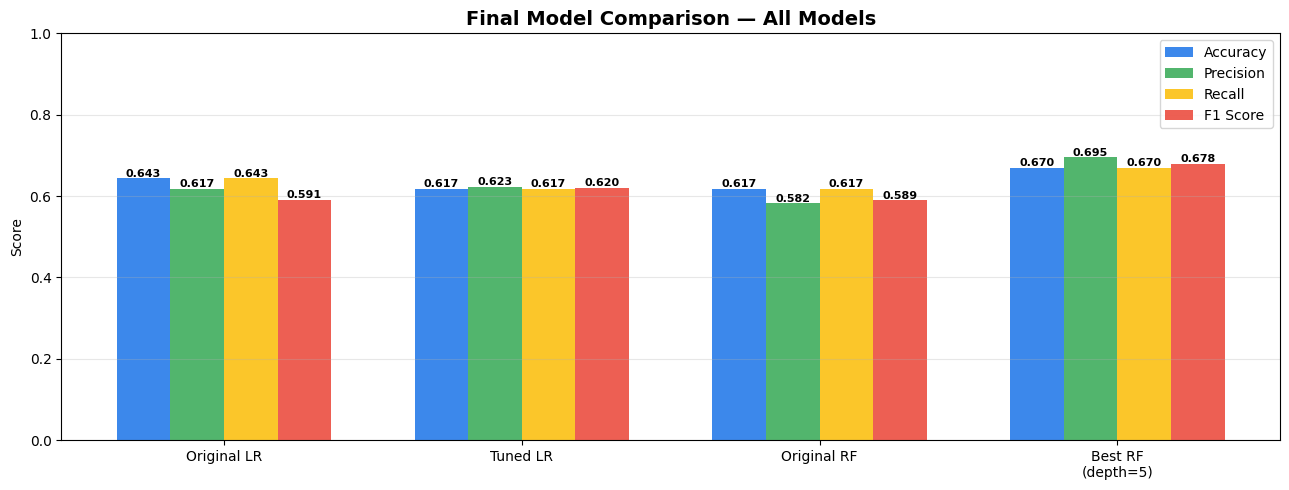

In [161]:
all_models = {
    "Original LR":  model.predict(x_test),
    "Tuned LR":     model_best.predict(x_test),
    "Original RF":  model_RF.predict(x_test)
    "Best RF\n(depth=5)": pred_rf_best,
}

summary_rows = []
for name, preds in all_models.items():
    summary_rows.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds, average="weighted"), 4),
        "Recall":    round(recall_score(y_test, preds, average="weighted"), 4),
        "F1 Score":  round(f1_score(y_test, preds, average="weighted"), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
print(summary_df)

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
x_pos = np.arange(len(summary_df)); w = 0.18
metric_colors = ["#1a73e8","#34a853","#fbbc04","#ea4335"]
for i, (metric, color) in enumerate(zip(summary_df.columns, metric_colors)):
    bars = ax.bar(x_pos + i*w - w*1.5, summary_df[metric], w,
                  label=metric, color=color, alpha=0.85)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004,
                f"{b.get_height():.3f}", ha="center", fontsize=8, fontweight="bold")
ax.set_xticks(x_pos); ax.set_xticklabels(summary_df.index, fontsize=10)
ax.set_ylim(0, 1); ax.set_ylabel("Score")
ax.set_title("Final Model Comparison — All Models", fontsize=14, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

In [165]:
import joblib

# Verify it works by reloading
loaded_model_RF = joblib.load("fifa_best_RF_model.pkl")
print("Random Forest model reloaded successfully")
loaded_model_LR = joblib.load("FIFA_best_LR_model.pkl")
print("Logistic Regression model reloaded successfully")

# Correctly print the accuracy scores
print("Final Accuracy RF:", round(accuracy_score(y_test, loaded_model_RF.predict(x_test)), 4))
print("Final Accuracy LR:", round(accuracy_score(y_test, loaded_model_LR.predict(x_test)), 4))

Random Forest model reloaded successfully
Logistic Regression model reloaded successfully
Final Accuracy RF: 0.6696
Final Accuracy LR: 0.6174


# Best Models Reports

## ROC curve for Best models

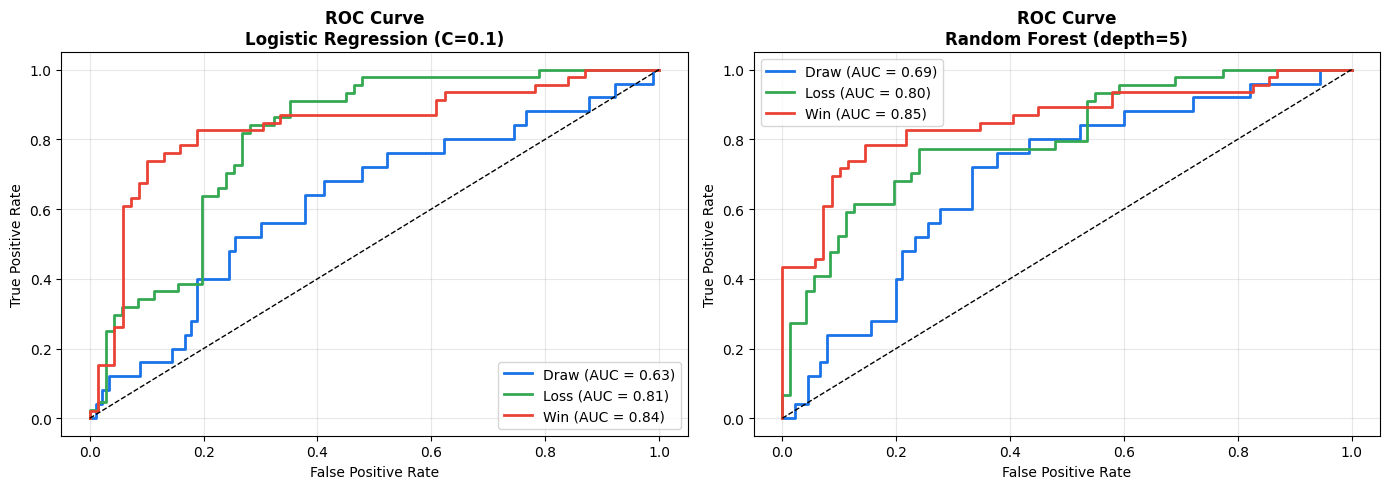

In [168]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#1a73e8", "#34a853", "#ea4335"]
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

for ax, model_p, preds, name in zip(
        axes,
        [model_best, model_RF_best],
        [model_best.predict_proba(x_test), model_RF_best.predict_proba(x_test)],
        ["Logistic Regression (C=0.1)", "Random Forest (depth=5)"]):

    for i, (cls, color) in enumerate(zip(lb.classes_, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], preds[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{cls} (AUC = {roc_auc:.2f})")
    ax.plot([0,1],[0,1], "k--", linewidth=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve\n{name}", fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

##precision-recall curve

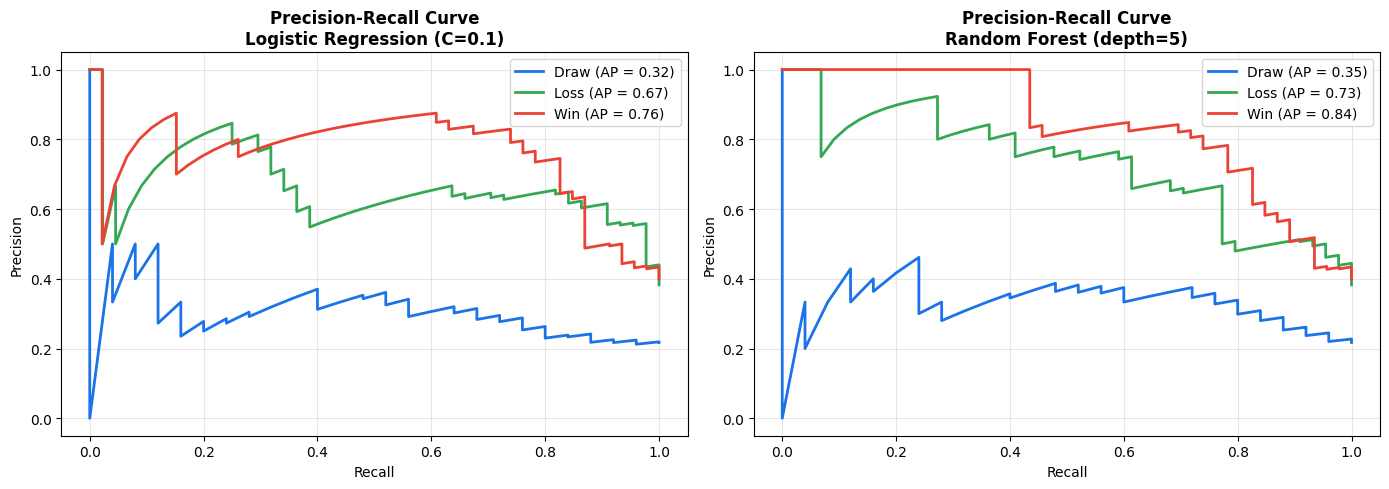

In [169]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#1a73e8", "#34a853", "#ea4335"]

for ax, model_p, name in zip(
        axes,
        [model_best.predict_proba(x_test), model_RF_best.predict_proba(x_test)],
        ["Logistic Regression (C=0.1)", "Random Forest (depth=5)"]):

    for i, (cls, color) in enumerate(zip(lb.classes_, colors)):
        prec, rec, _ = precision_recall_curve(y_test_bin[:, i], model_p[:, i])
        ap = average_precision_score(y_test_bin[:, i], model_p[:, i])
        ax.plot(rec, prec, color=color, linewidth=2,
                label=f"{cls} (AP = {ap:.2f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall Curve\n{name}", fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

##Prediction confidence distribution

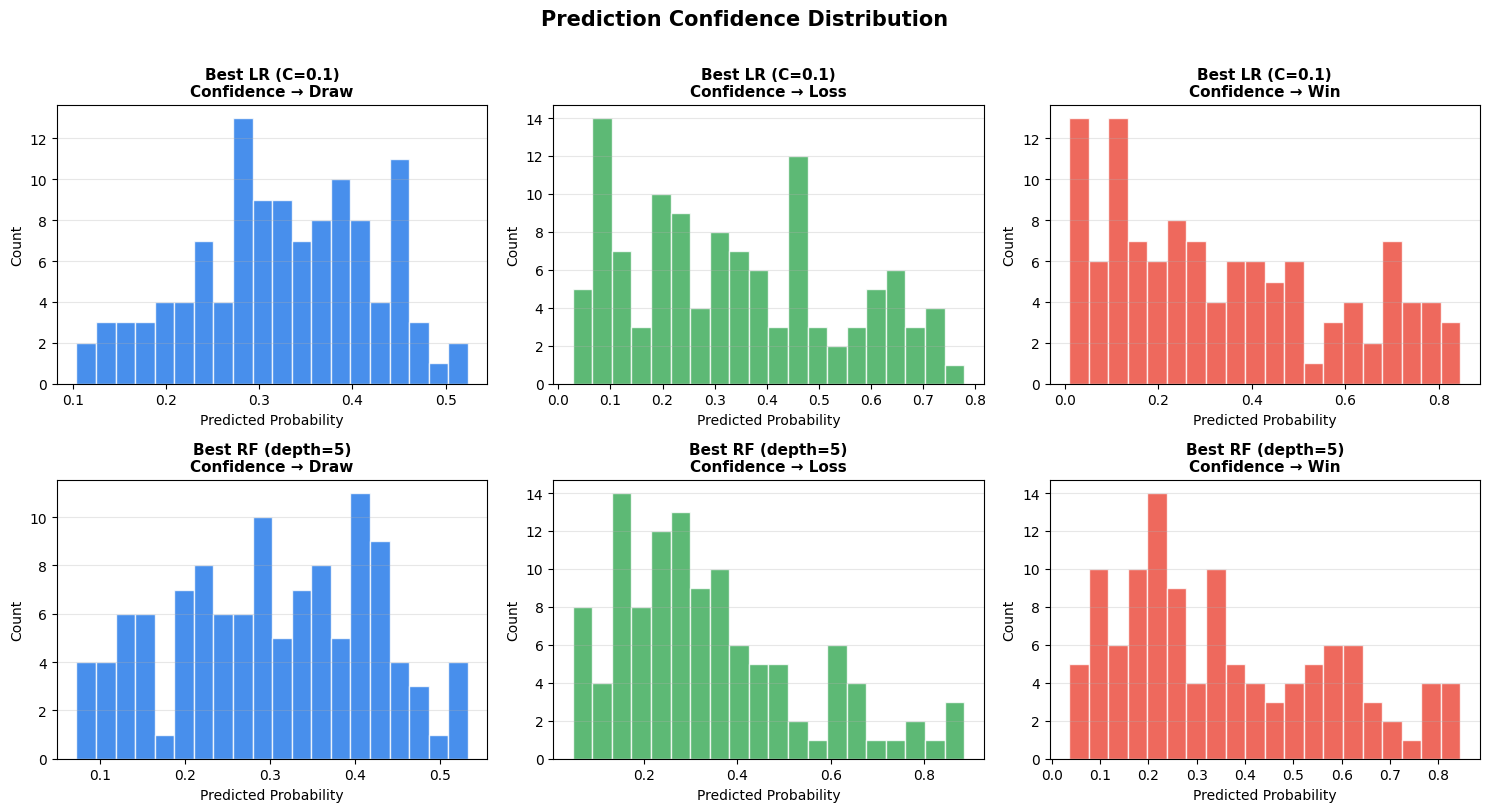

In [170]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
classes = lb.classes_

for row, (proba, name) in enumerate(zip(
        [model_best.predict_proba(x_test), model_RF_best.predict_proba(x_test)],
        ["Best LR (C=0.1)", "Best RF (depth=5)"])):
    for col, (cls, color) in enumerate(zip(classes, ["#1a73e8","#34a853","#ea4335"])):
        ax = axes[row][col]
        ax.hist(proba[:, col], bins=20, color=color, alpha=0.8, edgecolor="white")
        ax.set_title(f"{name}\nConfidence → {cls}", fontweight="bold", fontsize=11)
        ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Count")
        ax.grid(axis="y", alpha=0.3)

plt.suptitle("Prediction Confidence Distribution", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

##Side by Side Confusion Matrices

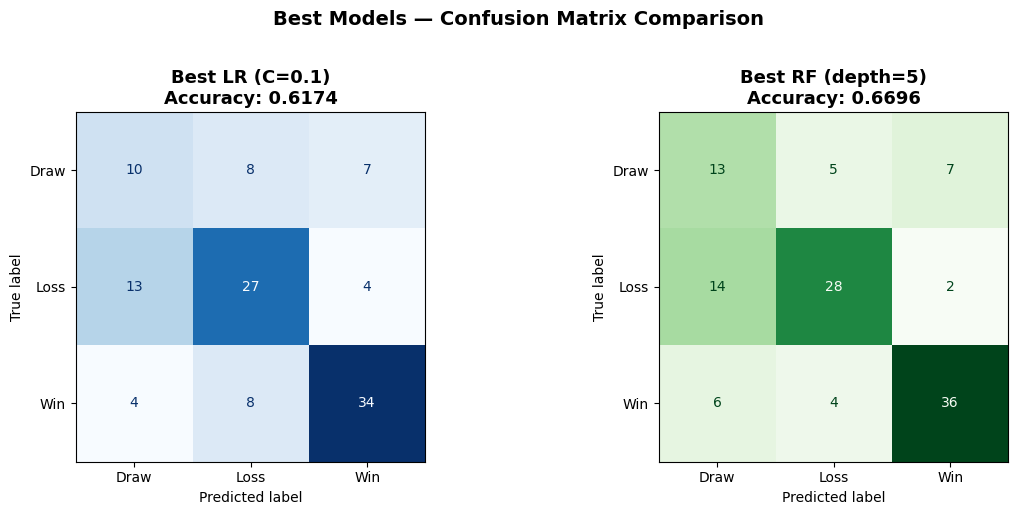

In [172]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cmaps = ["Blues", "Greens"]

for ax, preds, name, cmap in zip(
        axes,
        [model_best.predict(x_test), model_RF_best.predict(x_test)],
        ["Best LR (C=0.1)", "Best RF (depth=5)"],
        cmaps):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Draw","Loss","Win"])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc = accuracy_score(y_test, preds)
    ax.set_title(f"{name}\nAccuracy: {acc:.4f}", fontsize=13, fontweight="bold")

plt.suptitle("Best Models — Confusion Matrix Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

## Per class Win/Loss/Draw performance radar chart

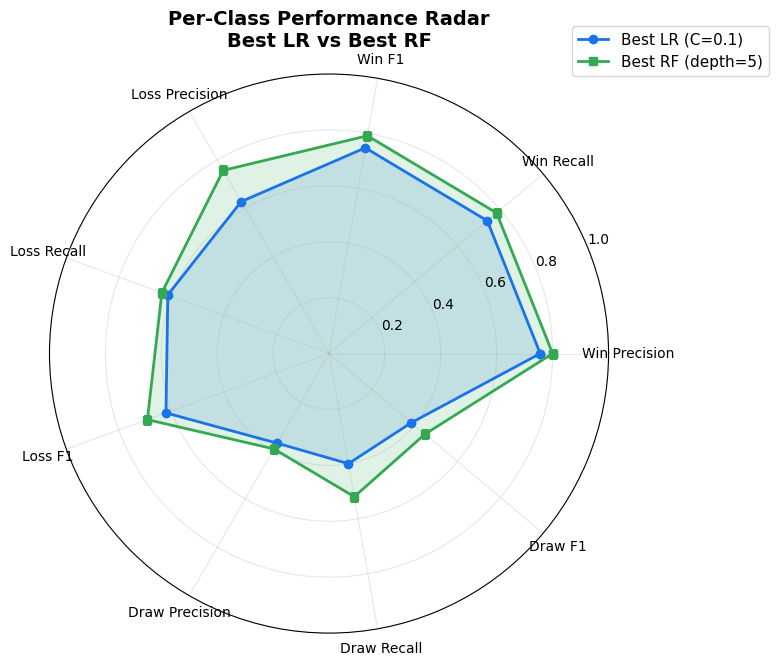

In [173]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ["Win Precision","Win Recall","Win F1",
              "Loss Precision","Loss Recall","Loss F1",
              "Draw Precision","Draw Recall","Draw F1"]

def get_class_metrics(y_true, y_pred):
    r = classification_report(y_true, y_pred, output_dict=True)
    vals = []
    for cls in ["Win","Loss","Draw"]:
        if cls in r:
            vals += [r[cls]["precision"], r[cls]["recall"], r[cls]["f1-score"]]
        else:
            vals += [0, 0, 0]
    return vals

lr_vals = get_class_metrics(y_test, model_best.predict(x_test))
rf_vals = get_class_metrics(y_test, model_RF_best.predict(x_test))

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
lr_vals += lr_vals[:1]
rf_vals += rf_vals[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, lr_vals, "o-", linewidth=2, color="#1a73e8", label="Best LR (C=0.1)")
ax.fill(angles, lr_vals, alpha=0.15, color="#1a73e8")
ax.plot(angles, rf_vals, "s-", linewidth=2, color="#34a853", label="Best RF (depth=5)")
ax.fill(angles, rf_vals, alpha=0.15, color="#34a853")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("Per-Class Performance Radar\nBest LR vs Best RF",
             fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Learning curve

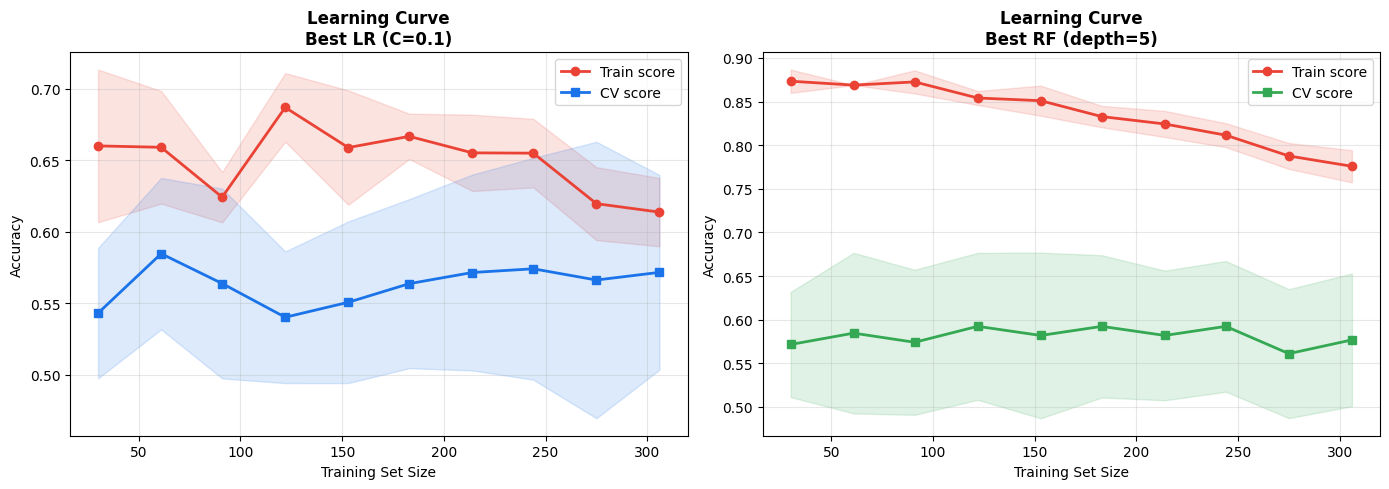

In [174]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_sizes = np.linspace(0.1, 1.0, 10)

for ax, model_p, name, color in zip(
        axes,
        [model_best, model_RF_best],
        ["Best LR (C=0.1)", "Best RF (depth=5)"],
        ["#1a73e8", "#34a853"]):

    train_sz, train_sc, test_sc = learning_curve(
        model_p, x, y, cv=5,
        train_sizes=train_sizes,
        scoring="accuracy", n_jobs=-1)

    train_mean = train_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    test_mean  = test_sc.mean(axis=1)
    test_std   = test_sc.std(axis=1)

    ax.plot(train_sz, train_mean, "o-", color="#ea4335", linewidth=2, label="Train score")
    ax.fill_between(train_sz, train_mean-train_std, train_mean+train_std, alpha=0.15, color="#ea4335")
    ax.plot(train_sz, test_mean,  "s-", color=color,    linewidth=2, label="CV score")
    ax.fill_between(train_sz, test_mean-test_std,  test_mean+test_std,  alpha=0.15, color=color)
    ax.set_xlabel("Training Set Size"); ax.set_ylabel("Accuracy")
    ax.set_title(f"Learning Curve\n{name}", fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Final research summary metrics table with styling

In [175]:
from sklearn.metrics import matthews_corrcoef

def full_metrics(y_true, y_pred, proba):
    lb2 = LabelBinarizer().fit(y_true)
    y_bin = lb2.transform(y_true)
    aucs = [auc(*roc_curve(y_bin[:,i], proba[:,i])[:2])
            for i in range(len(lb2.classes_))]
    return {
        "Accuracy":       round(accuracy_score(y_true, y_pred), 4),
        "Precision (W)":  round(precision_score(y_true, y_pred, average="weighted"), 4),
        "Recall (W)":     round(recall_score(y_true, y_pred, average="weighted"), 4),
        "F1 (W)":         round(f1_score(y_true, y_pred, average="weighted"), 4),
        "MCC":            round(matthews_corrcoef(y_true, y_pred), 4),
        "AUC (macro)":    round(np.mean(aucs), 4),
    }

results_final = {
    "Best LR (C=0.1)":    full_metrics(y_test, model_best.predict(x_test),
                                        model_best.predict_proba(x_test)),
    "Best RF (depth=5)":  full_metrics(y_test, model_RF_best.predict(x_test),
                                        model_RF_best.predict_proba(x_test)),
}

final_df = pd.DataFrame(results_final).T
print(final_df)
final_df.style\
    .background_gradient(cmap="YlGn", axis=0)\
    .format("{:.4f}")\
    .set_caption("Final Research Model Comparison")\
    .set_table_styles([{"selector":"caption",
                        "props":[("font-size","14px"),
                                 ("font-weight","bold")]}])

                   Accuracy  Precision (W)  Recall (W)  F1 (W)     MCC  \
Best LR (C=0.1)      0.6174         0.6230      0.6174  0.6200  0.4110   
Best RF (depth=5)    0.6696         0.6952      0.6696  0.6785  0.5011   

                   AUC (macro)  
Best LR (C=0.1)         0.7576  
Best RF (depth=5)       0.7830  


,Accuracy,Precision (W),Recall (W),F1 (W),MCC,AUC (macro)
Best LR (C=0.1),0.6174,0.6230,0.6174,0.6200,0.4110,0.7576
Best RF (depth=5),0.6696,0.6952,0.6696,0.6785,0.5011,0.7830


In [183]:
# Step 1 — install nbconvert
!pip install nbconvert -q

# Step 2 — install chromium for PDF rendering
!apt-get install -y chromium-browser -q

# Step 3 — convert your notebook to PDF, explicitly saving to /content/
# Use the environment variable _NB_PATH to get the path of the current notebook
!jupyter nbconvert --to pdf --output-dir "/content/" "$_NB_PATH"

print("✅ PDF created!")

Reading package lists...
Building dependency tree...
Reading state information...
chromium-browser is already the newest version (1:85.0.4183.83-0ubuntu2.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/LinearRegression.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Applic

In [4]:
import os

# Search for your notebook file
for root, dirs, files_list in os.walk("/content"):
    for file in files_list:
        if file.endswith(".ipynb"):
            print(os.path.join(root, file))

In [1]:
from google.colab import files
import os

# Get the filename from the _NB_PATH environment variable
notebook_path = os.environ.get('_NB_PATH', 'Untitled.ipynb')
notebook_filename = os.path.basename(notebook_path)
pdf_filename = notebook_filename.replace(".ipynb", ".pdf")

files.download(f"/content/{pdf_filename}")

FileNotFoundError: Cannot find file: /content/LinearRegression.ipynb.pdf

In [3]:
import os

# Search for your notebook file
for root, dirs, files_list in os.walk("/content"):
    for file in files_list:
        if file.endswith(".ipynb"):
            print(os.path.join(root, file))